---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 5**: RAG System for Fordham University

### 📅 **Due Date**: Day of Lecture 7, 11:59 PM

### Difficulty: ★★★★☆


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll complete the RAG (Retrieval Augmented Generation) system you started building in Lecture 5. You will build an end-to-end pipeline that can answer questions about Fordham University using real data scraped from the Fordham website.

This is an open-ended assignment — there is no single right implementation, and you're encouraged to experiment with chunking strategies, embedding models, prompt design, and retrieval parameters to improve your system. **I will grade your system by testing it with specific questions that I know the answer to.**

---

## Instructions

- You may use ChatGPT, Claude, documentation, Stack Overflow, etc. When using external resources, briefly cite them in a comment.
- Your submission must include **pre-computed embeddings** and any other artifacts needed so that I can run your RAG system without recomputing anything expensive. Share it with us in a way that makes sense.
- Run all cells before submitting to ensure they work.

**Submission:**
1. Create a branch called `homework-5`
2. Commit and push your work (notebook + Streamlit app + saved embeddings/artifacts in `temp/`)
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Step 1: Load and Chunk the Fordham Website Data

In `data/fordham-website.zip` you'll find **~9,500 Markdown files** scraped from Fordham's website. Each file is one page — admissions info, program descriptions, faculty pages, financial aid, campus life, and more. The first line of every file is the **URL** of the page it was scraped from. The rest is the page content in Markdown.

Think about: chunk size, what to split on (paragraphs, headers, fixed length, etc.), whether chunks should overlap, and how to track which page each chunk came from.

In [1]:
# IMPORTS AND SET UP

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

# helpers imports
from helpers import (
    # Data loading
    load_wands_products, load_wands_queries, load_wands_labels,
    # BM25 
    build_index, score_bm25, search_bm25,
    # Evaluation
    evaluate_search,
    # Embeddings
    get_local_model, batch_embed_local,
    # Similarity
    batch_cosine_similarity,
    # Utility
    normalize_scores
)

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()


pd.set_option('display.max_colwidth', 80)
print("All imports successful!")


All imports successful!


In [2]:
## FOR GITHUB, CHANGE FILE PATH

In [ ]:
# PROCESS WEBSITE FILE & CREATE DATAFRAME

import zipfile
import pandas as pd
import io

zip_file_path = '/Users/kmorris22/ai-engineering-fordham/data/fordham-website.zip'

data_list = []

# Open the zip file
with zipfile.ZipFile(zip_file_path, 'r') as z:
    # Iterate through every file in the archive
    for filename in z.namelist():
        # Ensure we only process markdown files (and skip directories)
        if filename.endswith('.md'):
            with z.open(filename) as f:
                try:
                    # Decode bytes to string
                    full_text = f.read().decode('utf-8')
                    
                    # Split into lines to separate URL from Content
                    lines = full_text.split('\n')
                    
                    # 1. Extract URL (First line)
                    url = lines[0].strip() if lines else None
                    
                    # 2. Extract Content (Everything else)
                    content_lines = lines[1:]
                    content = "\n".join(content_lines).strip()
                    
                    # 3. Extract Page Title
                    # logic: Find the first line that starts with '# ' (H1 tag)
                    page_title = None
                    for line in content_lines:
                        clean_line = line.strip()
                        if clean_line.startswith('# '):
                            page_title = clean_line.replace('# ', '').strip()
                            break
                    
                    # Fallback: if no H1 found, use the filename or first non-empty line
                    if not page_title:
                        page_title = filename.replace('.md', '').replace('_', ' ').title()

                    data_list.append({
                        'url': url,
                        'filename': filename,
                        'page_title': page_title,
                        'content': content
                    })
                    
                except Exception as e:
                    print(f"Could not process {filename}: {e}")

# Create the DataFrame
df = pd.DataFrame(data_list)

# Reorder columns as requested
df = df[['url', 'filename', 'page_title', 'content']]

# --- Look at the Data ---
print(f"Successfully loaded {len(df)} files.")
print("-" * 30)
print("Dataframe Info:")
print(df.info())
print("-" * 30)
print("First 5 Rows:")
print(df.head())

Successfully loaded 9551 files.
------------------------------
Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   url         9551 non-null   str  
 1   filename    9551 non-null   str  
 2   page_title  9551 non-null   str  
 3   content     9551 non-null   str  
dtypes: str(4)
memory usage: 298.6 KB
None
------------------------------
First 5 Rows:
                                                         url  \
0                                   https://www.fordham.edu/   
1                           https://www.fordham.edu/research   
2                               https://www.fordham.edu/ccel   
3  https://www.fordham.edu/fordham-college-at-lincoln-center   
4                          https://www.fordham.edu/academics   

                               filename  \
0                              index.md   
1                           resea

In [4]:
# DOUBLE CHECK DF

# Look at a sample doc to ensure it was processed correctly

doc = df.iloc[1]

print(f"URL: {doc['url']}")
print(f"Filename: {doc['filename']}")
print(f"Page Title: {doc['page_title']}")
print("-" * 30)
print("Content Preview (first 500 chars):\n")
print(doc['content'][:500])

URL: https://www.fordham.edu/research
Filename: research.md
Page Title: Research
------------------------------
Content Preview (first 500 chars):

Uncovering the Limitless Possibilities of Science

The Fordham Undergraduate Research Journal, or FURJ, is a student-run journal that features high quality, peer-reviewed, original research.

The Graduate School of Arts and Sciences is pleased to support the research efforts of students. Find the right grant for your graduate level research.

Join us for the upcoming Annual Undergraduate Research Symposium.

Fordham and four of our neighbors in the Bronx have created a new model for scientific r


In [5]:
# CHUNKS BASED ON WORD COUNT REVISED, WITH SOME OVERLAP
import pandas as pd

def chunk_text(text, target_word_count=200, overlap=20):
    """
    Splits text into overlapping chunks based on word count.
    
    Args:
        text (str): The content to split.
        target_word_count (int): Approximate words per chunk.
        overlap (int): Number of words to overlap between chunks.
        
    Returns:
        list of str: The text chunks.
    """
    if not text:
        return []
        
    # Split text into words (simple whitespace split)
    words = text.split()
    
    # If document is shorter than chunk size, return it as one chunk
    if len(words) <= target_word_count:
        return [" ".join(words)]
    
    chunks = []
    start_index = 0
    
    while start_index < len(words):
        # Define the end of the window
        end_index = start_index + target_word_count
        
        # Create the chunk
        chunk_words = words[start_index:end_index]
        chunk_text = " ".join(chunk_words)
        chunks.append(chunk_text)
        
        # Move the window forward, subtracting the overlap
        start_index = end_index - overlap
        
        # Break if we've processed the whole text (prevents infinite loops at end)
        if start_index >= len(words):
            break
            
    return chunks

# --- Main Processing Loop ---

chunked_data_list = []

# Iterate through your existing dataframe
for index, row in df.iterrows():
    # Generate chunks for the current document
    # 200 words is roughly 1000 characters (good for most embedding models)
    chunks = chunk_text(row['content'], target_word_count=200, overlap=20)
    
    for chunk_id, content in enumerate(chunks):
        chunked_data_list.append({
            'original_filename': row['filename'],
            'url': row['url'],
            'page_title': row['page_title'],
            'chunk_id': chunk_id,
            'content': content
        })

# Create the new Chunked DataFrame
chunked_df = pd.DataFrame(chunked_data_list)

# --- Inspection ---
print(f"Original Documents: {len(df)}")
print(f"Total Chunks Generated: {len(chunked_df)}")
print("-" * 30)
print("First Chunk Example:")
print(chunked_df.iloc[0]['content'])
print("-" * 30)
print("Dataframe Info:")
chunked_df.info()

Original Documents: 9551
Total Chunks Generated: 33333
------------------------------
First Chunk Example:
## Doing Good That Becomes Greater As The Jesuit University of New York We’re located in New York City—driven by our Jesuit values and tackling today’s most pressing issues at the center of the world stage. ## We Are Leaders, Dreamers, Achievers, And Doers With sound hearts, strong minds, and the wisdom to take charge, generations of Rams have found what they have needed to grow—the opportunities, connections, and support of this community. ## From Winding Elms to Bustling City Blocks With residential campuses in the Bronx and Manhattan, as well as campuses in Westchester and London, Fordham provides endless opportunities to start working toward your career and building the life you want. ## We’re Drawn to Where We’re Needed Most Explore how our values come to life: how Fordham’s students, faculty, and alumni contribute to society and make lives better. **Notice of Nondiscriminato

In [6]:
chunked_df

,original_filename,url,page_title,chunk_id,content
0,index.md,https://www.fordham.edu/,Index,0,## Doing Good That Becomes Greater As The Jesuit University of New York We’r...
1,index.md,https://www.fordham.edu/,Index,1,"the basis of race, color, national and ethnic origin in administration of it..."
2,research.md,https://www.fordham.edu/research,Research,0,Uncovering the Limitless Possibilities of Science The Fordham Undergraduate ...
3,research.md,https://www.fordham.edu/research,Research,1,revolutionary way to head them off and stay one step ahead of the … Isaie Do...
4,research.md,https://www.fordham.edu/research,Research,2,"chance to dive into her research project related to ALS, a neurodegenerative..."
...,...,...,...,...,...
33328,fordham-college-at-lincoln-center_academics_pre-professional-programs_pre-he...,https://www.fordham.edu/fordham-college-at-lincoln-center/academics/pre-prof...,Curriculum and Coursework in Pre-Health at FCLC,0,# Curriculum and Coursework in Pre-Health at FCLC Students focused on enteri...
33329,fordham-college-at-lincoln-center_academics_pre-professional-programs_pre-he...,https://www.fordham.edu/fordham-college-at-lincoln-center/academics/pre-prof...,Curriculum and Coursework in Pre-Health at FCLC,1,are required to take the following coursework to meet the required competenc...
33330,fordham-college-at-lincoln-center_academics_pre-professional-programs_pre-he...,https://www.fordham.edu/fordham-college-at-lincoln-center/academics/pre-prof...,Committee on Health Professions at FCLC,0,# Committee on Health Professions at FCLC **The Fordham College Lincoln Cent...
33331,fordham-college-at-lincoln-center_academics_pre-professional-programs_pre-he...,https://www.fordham.edu/fordham-college-at-lincoln-center/academics/pre-prof...,Committee on Health Professions at FCLC,1,with members of the Committee. Candidates who indicate intent to participate...


Calculating token counts...

Distribution of Chunk Sizes (Tokens):
------------------------------
count    33333.000000
mean       294.029520
std        158.191781
min          1.000000
25%        235.000000
50%        275.000000
75%        341.000000
max       4782.000000
Name: token_count, dtype: float64

Histogram saved as 'chunk_size_distribution_tokens.png'

LONGEST CHUNK DETAILS (BY TOKEN COUNT)
Source File  : Unknown
Page Title   : ERASED-Geographies of Black Displacement
Chunk ID     : 2
Token Count  : 4782 tokens
--------------------------------------------------
Content Preview (First 500 chars):
will take place at the beginning of the fall 2023 semester. **Project status** Complete **Resources: ** **Projects, Initiatives, and Organizations:** - DISPLACING Blackness: Cartographies of Violence, Extraction, and Disposability: [https://www.displacingblackness.com/](https://urldefense.proofpoint.com/v2/url?u=https-3A__www.displacingblackness.com_&d=DwMFaQ&c=aqMfXOEvEJQh2iQMCb7Wy8

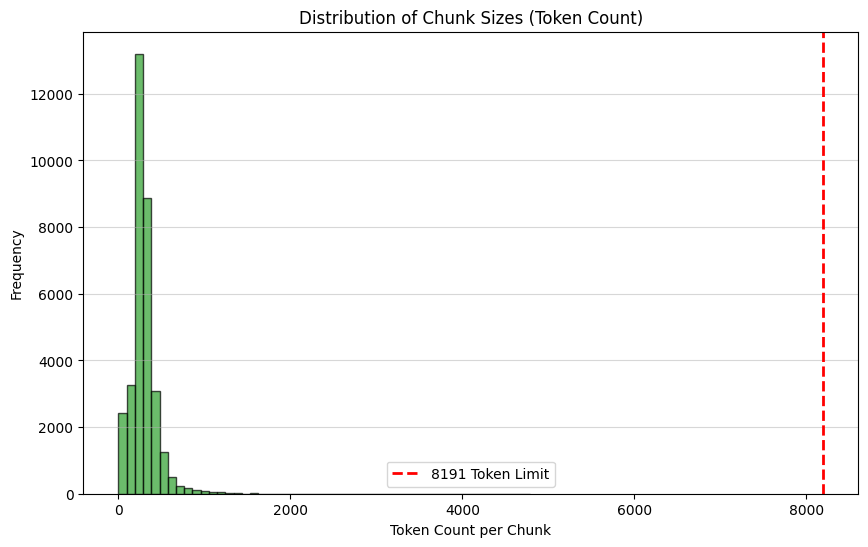

In [7]:
# CHeck CHUNKS BY TOKEN

import matplotlib.pyplot as plt
import tiktoken

# 1. Identify the text column (handle naming differences)
text_col = 'content' if 'content' in chunked_df.columns else 'content'

# 2. Calculate TOKEN counts using tiktoken
# 'cl100k_base' is the specific encoder for OpenAI's embedding-3 and GPT-4 models
enc = tiktoken.get_encoding("cl100k_base")

def get_token_count(text):
    # Handle NaN or non-string inputs safely
    if not isinstance(text, str):
        return 0
    return len(enc.encode(text))

print("Calculating token counts...")
chunked_df['token_count'] = chunked_df[text_col].apply(get_token_count)

# 3. Print descriptive statistics
print("\nDistribution of Chunk Sizes (Tokens):")
print("-" * 30)
print(chunked_df['token_count'].describe())

# 4. Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(chunked_df['token_count'], bins=50, color='#2ca02c', edgecolor='black', alpha=0.7)
plt.title('Distribution of Chunk Sizes (Token Count)')
plt.xlabel('Token Count per Chunk')
plt.ylabel('Frequency')

# Visual check: 8192 Token Limit
plt.axvline(x=8191, color='r', linestyle='--', linewidth=2, label='8191 Token Limit')
plt.legend()
plt.grid(axis='y', alpha=0.5)

# Save the plot
plt.savefig('chunk_size_distribution_tokens.png')
print("\nHistogram saved as 'chunk_size_distribution_tokens.png'")

# 5. Find and Print the Longest Chunk
longest_chunk_idx = chunked_df['token_count'].idxmax()
longest_chunk_row = chunked_df.loc[longest_chunk_idx]

print("\n" + "="*50)
print("LONGEST CHUNK DETAILS (BY TOKEN COUNT)")
print("="*50)
print(f"Source File  : {longest_chunk_row.get('filename', 'Unknown')}")
print(f"Page Title   : {longest_chunk_row.get('page_title', 'Unknown')}")
print(f"Chunk ID     : {longest_chunk_row.get('chunk_id', 'Unknown')}")
print(f"Token Count  : {longest_chunk_row['token_count']} tokens")
print("-" * 50)
print("Content Preview (First 500 chars):")
print(str(longest_chunk_row[text_col])[:500] + "...") 
print("="*50)

# 6. Explicit Check for Overflow
oversized_chunks = chunked_df[chunked_df['token_count'] > 8191]
if not oversized_chunks.empty:
    print(f"\n⚠️ WARNING: Found {len(oversized_chunks)} chunks exceeding the 8191 token limit.")
    print("Indices:", oversized_chunks.index.tolist())
else:
    print("\n✅ All chunks are within the 8191 token limit.")

---

## Step 2: Embed the Chunks

Turn each chunk into a vector so you can search over them. You can use a local model or an API model — your choice.

Once you've created your embeddings, **save them somewhere** so you (and I) don't have to redo this step. Save the chunk metadata too (text, source URL, etc.).

In [8]:
# CREATE CHUNKS

##NOTES
# 30 is too many
# first 20 is good
# the issue is batch size

#chunks_sample = chunked_df.sample(n=100, random_state=42).reset_index(drop=True)

#chunks_sample = chunked_df.head(5000).copy()


#chunks_sample = chunked_df.sample(n=100, random_state=42).reset_index(drop=True)
chunks_sample = chunked_df.copy()
print(f"Working with {len(chunks_sample):,} chunks")

# Check
chunks_sample.describe()
chunks_sample


# 1. Create combined text field
chunks_sample['embed_text'] = (
    chunks_sample['page_title'].fillna('') + '\n\n' +
    chunks_sample['content'].fillna('')
)

# 2. Settings
BATCH_SIZE = 20
all_embeddings = []
total_rows = len(chunks_sample)

print(f"Starting embedding for {total_rows} rows in batches of {BATCH_SIZE}...")
start_total = time.time()

# 3. Loop through data in chunks
for i in range(0, total_rows, BATCH_SIZE):
    # Slice the batch
    batch_texts = chunks_sample['embed_text'].iloc[i : i + BATCH_SIZE].tolist()
    
    print(f"Processing batch {i} to {i + len(batch_texts)}...")
    batch_start = time.time()
    
    try:
        # OpenAI model call for current batch
        response = litellm.embedding(
            model="text-embedding-3-small",
            input=batch_texts
        )
        
        # Extract embeddings from the response object
        # We iterate through 'data' to get every embedding in the batch
        batch_embeddings = [item['embedding'] for item in response['data']]
        all_embeddings.extend(batch_embeddings)
        
        #print(f"Batch completed in {time.time() - batch_start:.1f}s")
        
        # Optional: Sleep briefly to avoid hitting Rate Limits (Requests Per Minute)
        time.sleep(0.5) 

    except Exception as e:
        print(f"❌ Error on batch starting at index {i}: {e}")
        # Optional: break or continue depending on how you want to handle errors
        break

# 4. Finalize results
final_embeddings_np = np.array(all_embeddings)

print("\n--- FINAL STATS ---")
print(f"Total time: {time.time() - start_total:.1f}s")
print(f"Total embeddings generated: {len(all_embeddings)}")
print(f"Embeddings shape: {final_embeddings_np.shape}")

# 5. Assign back to your dataframe (ensure lengths match first)
if len(all_embeddings) == len(chunks_sample):
    chunks_sample['embedding'] = all_embeddings
else:
    print("Warning: Embedding count does not match dataframe length (likely due to an error).")

Working with 33,333 chunks
Starting embedding for 33333 rows in batches of 20...
Processing batch 0 to 20...
Processing batch 20 to 40...
Processing batch 40 to 60...
Processing batch 60 to 80...
Processing batch 80 to 100...
Processing batch 100 to 120...
Processing batch 120 to 140...
Processing batch 140 to 160...
Processing batch 160 to 180...
Processing batch 180 to 200...
Processing batch 200 to 220...
Processing batch 220 to 240...
Processing batch 240 to 260...
Processing batch 260 to 280...
Processing batch 280 to 300...
Processing batch 300 to 320...
Processing batch 320 to 340...
Processing batch 340 to 360...
Processing batch 360 to 380...
Processing batch 380 to 400...
Processing batch 400 to 420...
Processing batch 420 to 440...
Processing batch 440 to 460...
Processing batch 460 to 480...
Processing batch 480 to 500...
Processing batch 500 to 520...
Processing batch 520 to 540...
Processing batch 540 to 560...
Processing batch 560 to 580...
Processing batch 580 to 600...

In [ ]:
# SAVE EMBEDDINGS 

# Save embeddings to ../temp/website_embeddings.npy
# Save products_sample to ../temp/chunks_sample.csv

# Define paths
temp_dir = Path("../temp")
temp_dir.mkdir(parents=True, exist_ok=True)

np.save(temp_dir / "website_embeddings.npy", final_embeddings_np)
chunks_sample.to_csv(temp_dir / "chunks_sample.csv", index=False)

In [ ]:
# Define paths
temp_dir = Path("../temp")

# Load embeddings back
print("\nLoading embeddings back...")
loaded_embeddings = np.load(temp_dir / "website_embeddings.npy")
print(f"  Loaded embeddings shape: {loaded_embeddings.shape}")

# Load chunks back
print("\nLoading chunks back...")
loaded_chunks = pd.read_csv(temp_dir / "chunks_sample.csv")
print(f"  Loaded chunks shape: {loaded_chunks.shape}")


Loading embeddings back...
  Loaded embeddings shape: (33333, 1536)

Loading chunks back...
  Loaded chunks shape: (33333, 8)


---

## Step 3: Retrieve

Build the **R** in RAG. Write a function that takes a question and returns the most relevant chunks. You can use semantic search, BM25, hybrid — whatever you think works best.

Test it on a few questions and eyeball whether the results make sense.

In [14]:
# based on search code from lesson 4



def semantic_search(query, loaded_embeddings, loaded_chunks, k=10):
    """Search products using local embedding similarity."""
    # 1. Embed the query
    #model = get_local_model("all-MiniLM-L6-v2")
    #query_emb = model.encode(query, convert_to_numpy=True)

    response = litellm.embedding(model="text-embedding-3-small", input=[query])
    query_emb = np.array(response.data[0]["embedding"])
    
    # 2. Calculate similarity to all products
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    
    # 3. Get top-k indices
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Build results DataFrame
    results = loaded_chunks.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results

# Test semantic search!
results = semantic_search("What programs does the Gabelli School of Business offer?", loaded_embeddings, loaded_chunks)
results



,original_filename,url,page_title,chunk_id,content,token_count,embed_text,embedding,similarity,rank
8810,gabelli-school-of-business_academic-programs-and-admissions.md,https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-adm...,Gabelli Academic Programs and Admissions,0,# Gabelli Academic Programs and Admissions Our wide-ranging business school ...,86,Gabelli Academic Programs and Admissions\n\n# Gabelli Academic Programs and ...,"[-0.03938465, -0.013465038, 0.049912285, 0.050899252, 0.00020671947, -0.0370...",0.777678,1
225,gabelli-school-of-business.md,https://www.fordham.edu/gabelli-school-of-business,Gabelli School of Business,0,# Gabelli School of Business ## Graduate Business Programs – Advance Your Ca...,154,Gabelli School of Business\n\n# Gabelli School of Business ## Graduate Busin...,"[-0.05409107, 0.02411101, 0.017559236, 0.036100637, -0.02115253, -0.03308227...",0.775902,2
14835,info_20447_gabelli_school_of_business.md,https://www.fordham.edu/info/20447/gabelli_school_of_business,Gabelli School of Business,0,# Gabelli School of Business ## Graduate Business Programs – Advance Your Ca...,154,Gabelli School of Business\n\n# Gabelli School of Business ## Graduate Busin...,"[-0.054055907, 0.024116697, 0.017539416, 0.036109153, -0.021121578, -0.03306...",0.775821,3
9803,gabelli-school-of-business_academic-programs-and-admissions_graduate-program...,https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-adm...,Gabelli Graduate Academic Programs,0,# Gabelli Graduate Academic Programs ![Academic Programs](/media/home/school...,709,Gabelli Graduate Academic Programs\n\n# Gabelli Graduate Academic Programs !...,"[-0.076473914, 0.016542597, 0.035596356, 0.0118762385, 0.010225862, -0.03660...",0.775409,4
9564,gabelli-school-of-business_academic-programs-and-admissions_graduate-program...,https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-adm...,Graduate Programs,0,# Graduate Programs ![Graduate Business Education](/media/review/content-ass...,334,Graduate Programs\n\n# Graduate Programs ![Graduate Business Education](/med...,"[-0.067009464, 0.02614831, 0.01808454, 0.020312687, -0.0056381556, -0.018544...",0.749865,5
8811,gabelli-school-of-business_about.md,https://www.fordham.edu/gabelli-school-of-business/about,About Gabelli School of Business,0,# About Gabelli School of Business ![Gabelli talking to professor in front o...,201,About Gabelli School of Business\n\n# About Gabelli School of Business ![Gab...,"[-0.073585644, -0.01968887, 0.012658858, 0.050055634, 0.031622984, -0.037203...",0.736590,6
9914,gabelli-school-of-business_academic-programs-and-admissions_graduate-program...,https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-adm...,The Gabelli Advantage,1,"production floors of companies all over New York and across the globe, from ...",171,The Gabelli Advantage\n\nproduction floors of companies all over New York an...,"[-0.04661213, -0.012135661, 0.031755563, 0.05688023, 0.015360179, -0.0391418...",0.735254,7
20770,undergraduate-admission_admitted-students_academics-and-advising.md,https://www.fordham.edu/undergraduate-admission/admitted-students/academics-...,Academics and Advising,2,business—in New York City and across the world. And Gabelli's dual business ...,49,Academics and Advising\n\nbusiness—in New York City and across the world. An...,"[-0.024019107, -0.0067877434, 0.04584469, 0.050792307, 0.01665861, -0.003518...",0.731521,8
8976,gabelli-school-of-business_student-and-career-resources_undergraduate-studen...,https://www.fordham.edu/gabelli-school-of-business/student-and-career-resour...,Information for New Students,3,"experience, you also will find that the School offers the rich resources and...",239,"Information for New Students\n\nexperience, you also will find that the Scho...","[-0.047814604, 0.02335132, 0.03189325, 0.02337659, 0.03886832, -0.012591769,...",0.729189,9
9566,gabelli-school-of-business_academic-programs-and-ad

In [15]:
# Test queries
def pretty_print_results(results, max_chars=400):
    for _, row in results.iterrows():
        print("=" * 100)
        print(f"Rank: {row['rank']} | Similarity: {row['similarity']:.4f}")
        print(f"Title: {row['page_title']}")
        print(f"URL: {row['url']}")
        print("-" * 100)
        print(row['content'][:max_chars])
        print("\n")


test_queries = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid?",
    "Where is Fordham's campus?"
]

for query in test_queries:
    print("\n" + "#" * 120)
    print(f"QUERY: {query}")
    print("#" * 120)
    
    results = semantic_search(
        query,
        loaded_embeddings,
        loaded_chunks,
        
        k=5
    )
    
    pretty_print_results(results)


########################################################################################################################
QUERY: What programs does the Gabelli School of Business offer?
########################################################################################################################
Rank: 1 | Similarity: 0.7777
Title: Gabelli Academic Programs and Admissions
URL: https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-admissions
----------------------------------------------------------------------------------------------------
# Gabelli Academic Programs and Admissions Our wide-ranging business school programs won’t just shape your career – they’ll offer a transformative experience that will leave you ready to use business to create changes that benefit humanity. A 100-year legacy of curriculum that’s deeply aligned with industry and rooted in the liberal arts gives our graduates the agility, determination, and strategi


Rank: 2 | Similarity: 0

---

## Step 4: Generate

Build the **G** in RAG. Write a function that takes a question and the retrieved chunks, builds a prompt, and calls an LLM to generate an answer.

Think about: how to structure the prompt, what the LLM should do when the context doesn't contain the answer, and which model to use.

In [16]:
def generate_answer(query, context_chunks, urls):
    """
    Takes a query, context strings, and their corresponding URLs
    to generate an answer with a source list.
    """
    
    # 1. Prepare the context string with URLs included for the LLM to see
    context_items = []
    for i, (content, url) in enumerate(zip(context_chunks, urls)):
        context_items.append(f"Source {i+1} [URL: {url}]:\n{content}")
    
    context_text = "\n\n".join(context_items)
    
    # 2. Build the System Prompt
    system_prompt = """You are a helpful and accurate assistant for Fordham University. 
    Your task is to answer the user's question using ONLY the provided context. 
    
    - Summarize the answer clearly based on the context.
    - If the answer is NOT in the context, say: "I'm sorry, I don't have that information."
    - At the end of your response, provide a section titled "Sources:" followed by a 
      numbered list of the URLs you used to form the answer."""
    
    # 3. Build the User Prompt
    user_prompt = f"""
    Context:
    {context_text}
    
    Question: {query}
    
    Answer:
    """
    
    # 4. Call the LLM
    response = litellm.completion(
        model="openai/gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2
    )
    
    return response.choices[0].message.content

# --- INTEGRATION EXAMPLE ---

query = "Where is Fordham's campus?"

# Step 1: Get Chunks AND Metadata (assuming your search returns a dataframe with 'url')
search_results = semantic_search(query, loaded_embeddings, loaded_chunks, k=3)
retrieved_texts = search_results['content'].tolist()
retrieved_urls = search_results['url'].tolist() # Ensure your index has URL metadata

# Step 2: Generate Answer
answer = generate_answer(query, retrieved_texts, retrieved_urls)

print(f"QUERY: {query}")
print(f"ANSWER:\n{answer}")

QUERY: Where is Fordham's campus?
ANSWER:
Fordham University has multiple campuses located in New York City:

1. **Rose Hill Campus**: 441 E. Fordham Rd., Bronx, NY 10458. It features 85 acres of green space and is near the New York Botanical Garden and the Bronx Zoo.

2. **Lincoln Center Campus**: 113 West 60th Street, New York, NY 10023. This campus is situated in Manhattan's West Side, across from Lincoln Center for the Performing Arts.

3. **Westchester Campus**: 400 Westchester Avenue, West Harrison, NY 10604. This campus is located in a suburban area and offers a smaller campus environment.

Sources:
1. https://www.fordham.edu/summer-session/about/nyc-campuses
2. https://www.fordham.edu/about/campuses/rose-hill-campus
3. https://www.fordham.edu/graduate-school-of-social-service/about/campus-locations/westchester-campus


---

## Step 5: Wire it Together

Combine the previous steps into a single `rag(question)` function. Question in, answer out.

In [7]:
# INITIALIZE (DO ONCE)
# Define paths
temp_dir = Path("temp")
# Load embeddings 
loaded_embeddings = np.load(temp_dir / "website_embeddings.npy")

# Load chunks 
loaded_chunks = pd.read_csv(temp_dir / "chunks_sample.csv")

def batch_cosine_similarity(query_emb: np.ndarray, doc_embs: np.ndarray) -> np.ndarray:
    """
    Calculate cosine similarity between query and all documents.

    Args:
        query_emb: Query embedding vector
        doc_embs: Document embeddings matrix (num_docs, embedding_dim)

    Returns:
        Array of similarity scores for each document
    """
    query_norm = query_emb / np.linalg.norm(query_emb)
    doc_norms = doc_embs / np.linalg.norm(doc_embs, axis=1, keepdims=True)
    return doc_norms @ query_norm


In [8]:



def rag(query):
    k = 5


    #SEMANTIC SEARCH: Retrieves the top-k most relevant text chunks.
   
    # Embed the query via API
    response = litellm.embedding(model="text-embedding-3-small", input=[query])
    query_emb = np.array(response.data[0]["embedding"])
    
    # Calculate scores and sort
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    top_k_idx = np.argsort(-similarities)[:k]
    
    # Identify top chunks
    search_results = loaded_chunks.iloc[top_k_idx].copy()
    search_results['similarity'] = similarities[top_k_idx]
   
    #PROCESSS SEARCH RESULTS

    #only share unique url
    #search_results = search_results.drop_duplicates(subset=['url'], keep='first')
    
    # Format search results
    retrieved_texts = search_results['content'].tolist()
    retrieved_urls = search_results['url'].tolist() 

    # SET UP LLM 

    # Join chunk results so LLM can process 
    context_items = []
    for i, (content, url) in enumerate(zip(retrieved_texts, retrieved_urls)):
        context_items.append(f"Source {i+1} [URL: {url}]:\n{content}")
    
    context_text = "\n\n".join(context_items)
    
    # Build the System Prompt
    system_prompt = """You are a helpful and accurate assistant for Fordham University. 
    Your task is to answer the user's question using ONLY the provided context. 
    
    - Summarize the answer clearly based on the context.
    - If the answer is NOT in the context, say: "I'm sorry, I don't have that information."
    - At the end of your response, provide a section titled "Sources:" followed by a 
    numbered list of the URLs you used to form the answer."""
    
    # Build the User Prompt
    user_prompt = f"""
    Context:
    {context_text}
    
    Question: {query}
    
    Answer:
    """
    
    # Call the LLM
    response = litellm.completion(
        model="openai/gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2
    )
    
    answer = response.choices[0].message.content

    return answer


In [9]:
# Demonstrate your RAG system

demo_questions = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid at Fordham?",
    "What is the tuition for undergraduate students?",
    "Tell me about Fordham's campus locations.",
    "What research opportunities are available for students?",
]

for q in demo_questions:
    print(f"Q: {q}")
    answer = rag(q)
    print(f"A: {answer}")
    print("-" * 80)

Q: What programs does the Gabelli School of Business offer?
A: The Gabelli School of Business offers a variety of programs including three variants of the MBA program: full-time cohort MBA, Professional MBA (including part-time), and Executive MBA. Additionally, there are 13 specialized Master of Science programs in areas such as Accounting, Artificial Intelligence in Business, Business Analytics, Finance, Information Technology, Management, Marketing Intelligence, Media Management, Quantitative Finance, and Taxation. 

Sources:
1. https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-admissions
2. https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-admissions/graduate-programs/academic-programs
3. https://www.fordham.edu/gabelli-school-of-business/academic-programs-and-admissions/graduate-programs
--------------------------------------------------------------------------------
Q: How do I apply for financial aid at Fordham?
A: To apply for finan

---

## Step 6: Evaluate Your RAG System

A working RAG system is great — but how do you know it's actually *good*? You can't improve what you can't measure. In this step you'll build an evaluation framework using concepts from Lecture 6.

There are two things to evaluate in a RAG system:
- **Retrieval quality**: Are you finding the right chunks?
- **Answer quality**: Is the generated answer correct and grounded in the context?

### Build a test set

Create a test set of at least **10 question-answer pairs**. For each pair, provide the question and the expected answer (look it up in the data). Cover a range of question types — factual, procedural, about specific programs, etc.

### Evaluate retrieval

For each question, check whether the retrieved chunks actually contain relevant information. You can do this manually or automatically (e.g., use an LLM to judge relevance). Compute **context relevance** — the fraction of retrieved chunks that are actually useful.

### Evaluate answers with LLM-as-judge

Use an LLM to evaluate your system's answers on two dimensions:

1. **Faithfulness**: Does the answer only use information from the retrieved context? (No hallucination)
2. **Correctness**: Is the answer factually correct compared to the expected answer?

Use **structured outputs** (Pydantic) to get consistent scores from the judge. A starting schema is provided below — feel free to modify it.

In [20]:
from pydantic import BaseModel, Field

class RAGEvaluation(BaseModel):
    faithfulness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely hallucinated, 5=fully grounded in context"
    )
    faithfulness_reasoning: str = Field(
        ..., description="Brief explanation of the faithfulness score"
    )
    correctness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely wrong, 5=fully correct and complete"
    )
    correctness_reasoning: str = Field(
        ..., description="Brief explanation of the correctness score"
    )

In [21]:
# YOUR CODE HERE
# - Build your test set
# - Evaluate retrieval quality (context relevance)
# - Evaluate answer quality with LLM-as-judge (faithfulness + correctness)
# - Summarize your results

In [27]:
# BUILD A TEST SET - Generate 10 synthetic questions

import asyncio
import random
import textwrap

# 1. Define the Schema
class SyntheticQuestion(BaseModel):
    chain_of_thought: str = Field(description="Step-by-step reasoning about what makes a good question for this document")
    question: str = Field(description="A natural, specific question that can be answered using the document")
    answer: str = Field(description="The answer to the question")

# 2. Define Constraints
constraints = [
    "The question should be answerable in one word or a short phrase",
    "Frame the question as if a student is asking about Fordham University.",
    "Ask about a specific program, requirement, or location mentioned in the text.",
    "The question should require a specific detail found only in this document."
]

# 3. Modified Generation Function with URL
async def generate_fordham_question(doc_id: int, title: str, content: str, url: str) -> dict:
    """Generate a synthetic question based on Fordham document content."""
    constraint = random.choice(constraints)
    
    response = await litellm.acompletion(
        model="openai/gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": textwrap.dedent(f"""
                I will give you a document from the Fordham University website. 
                Generate a question that can be answered using the following content.
                
                Title: {title}
                Content: {content[:2000]}
                
                Rules:
                - Question must be natural and specific.
                - Do not mention 'the text' or 'the document'.
                - {constraint}
                - Must be answerable ONLY using the content provided.
                """
                ),
            }
        ],
        response_format=SyntheticQuestion,
    )
    
    # Parse and Return
    result = SyntheticQuestion.model_validate_json(response.choices[0].message.content)
    return {
        "source_doc_id": doc_id, 
        "source_url": url,           # Added URL here
        "question": result.question, 
        "answer": result.answer,
        "reasoning": result.chain_of_thought
    }

# 4. Execution Logic
sample_size = min(10, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

# Pass row["url"] into the function (ensure your df has a 'url' column)
tasks = [
    generate_fordham_question(idx, row["page_title"], row["content"], row["url"]) 
    for idx, row in sample_df.iterrows()
]

# Run concurrently
print(f"Generating {sample_size} questions... please wait.")
synthetic_results = await asyncio.gather(*tasks)

# Convert to DataFrame
synthetic_df = pd.DataFrame(synthetic_results)

# 5. Review Results
print("\n--- Synthetic QA Pairs Generated ---")
# Displaying the URL now as well
display(synthetic_df[['source_doc_id', 'source_url', 'question', 'answer']].head())

Generating 10 questions... please wait.

--- Synthetic QA Pairs Generated ---


,source_doc_id,source_url,question,answer
0,4731,https://www.fordham.edu/school-of-professional-and-continuing-studies/academ...,What is the program's focus area?,Hospitality investment and development
1,1468,https://www.fordham.edu/graduate-school-of-arts-and-sciences/student-resourc...,What skills do candidates with advanced degrees in STEM need to succeed in m...,Candidates with advanced degrees in STEM need to have critical thinking skil...
2,9037,https://www.fordham.edu/academics/research/office-of-research/events/symposi...,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,Responsible AI
3,7866,https://www.fordham.edu/academics/departments/psychology/events/anastasi-lec...,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,(Predicting) Replication Outcomes.
4,5570,https://www.fordham.edu/about/leadership-and-administration/administrative-o...,When can duplicate diplomas be ordered at Fordham University?,Duplicate diplomas are ordered twice a year in January and July.


In [28]:
synthetic_df

,source_doc_id,source_url,question,answer,reasoning
0,4731,https://www.fordham.edu/school-of-professional-and-continuing-studies/academ...,What is the program's focus area?,Hospitality investment and development,The document describes the Master of Science in Hospitality at Fordham Unive...
1,1468,https://www.fordham.edu/graduate-school-of-arts-and-sciences/student-resourc...,What skills do candidates with advanced degrees in STEM need to succeed in m...,Candidates with advanced degrees in STEM need to have critical thinking skil...,To create a question related to Fordham University's STEM Field Career Consu...
2,9037,https://www.fordham.edu/academics/research/office-of-research/events/symposi...,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,Responsible AI,"The document provides information about Dr. Dinesh Verma, his collaboration ..."
3,7866,https://www.fordham.edu/academics/departments/psychology/events/anastasi-lec...,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,(Predicting) Replication Outcomes.,"The document discusses the Anastasi Lecture of 2021, where Dr. Anna Dreber w..."
4,5570,https://www.fordham.edu/about/leadership-and-administration/administrative-o...,When can duplicate diplomas be ordered at Fordham University?,Duplicate diplomas are ordered twice a year in January and July.,The content outlines specific details about ordering duplicate diplomas from...
5,5613,https://www.fordham.edu/about/leadership-and-administration/administrative-o...,What is the role of the AVP and Controller at Fordham University?,The document does not provide specific details about the role of the AVP and...,"The document provides a brief overview of Fordham University, particularly f..."
6,7751,https://www.fordham.edu/academics/departments/theology/faculty/robert-davis,What is Prof. Robert Davis's primary area of research?,Prof. Davis's primary area of research is medieval Latin Christian thought a...,"To create a question based on Robert Davis's professional background, I need..."
7,1662,https://www.fordham.edu/school-of-law/give/giving-opportunities/parents-and-...,What is the minimum annual gift required to join the Parents and Family Lead...,"$20,000+",The document discusses a council dedicated to the parents and families of Fo...
8,8592,https://www.fordham.edu/academics/academic-resources/international-services/...,What is one condition for eligibility for a cap-gap extension?,Must be on approved OPT or in the 60-day grace period.,The document is focused on the cap-gap extension available for F-1 students ...
9,2164,https://www.fordham.edu/school-of-law/life-at-fordham-law/student-organizati...,Who is the president of the Black Law Students Association?,Feyi Idera,The document provides specific information about the Black Law Students Asso...


In [29]:
# EVALUATE RETRIEVAL QUALITY
# Evaluate retrieval on synthetic questions
# Key difference from qrels: each synthetic question has exactly 1 relevant doc (its source)


# We'll compute metrics at multiple values of k
k_values = [1, 3, 5, 10, 20]
max_k = 20

syn_rows = []

syn_rows = []

# Map chunk index -> document ID (source_doc_id is df index); needed for evaluation
if "doc_id" not in loaded_chunks.columns:
    url_to_doc_id = dict(zip(df["url"], df.index))
    loaded_chunks = loaded_chunks.copy()
    loaded_chunks["doc_id"] = loaded_chunks["url"].map(url_to_doc_id)

print(f"Evaluating retrieval for {len(synthetic_df)} synthetic questions...")

for _, row in synthetic_df.iterrows():
    source_id = row["source_doc_id"]
    question = row["question"]
    source_url = row["source_url"]

    # Search for the synthetic question
    #retrieved = table.search(question, query_type="vector").limit(max_k).to_list()
    #retrieved_ids = [r["doc_id"] for r in retrieved]

     # --- 1. Perform Semantic Search (Your logic) ---
    # Embed the synthetic question
    resp = litellm.embedding(model="text-embedding-3-small", input=[question])
    query_emb = np.array(resp.data[0]["embedding"])
    
    # Calculate similarities against your loaded embeddings
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    
    # Get the top-k chunk indices, then map to document IDs (loaded_chunks row i <-> loaded_embeddings row i)
    retrieved_indices = np.argsort(-similarities)[:max_k]
    retrieved_doc_ids = loaded_chunks.iloc[retrieved_indices]["doc_id"].tolist()

    # --- 2. Calculate Metrics ---
    for k in k_values:
        ids_at_k = retrieved_doc_ids[:k]
        # Binary relevance: was the source document retrieved in top-k?
        found = source_id in ids_at_k
        precision = (1.0 if found else 0.0) / k  # at most 1 relevant doc
        recall = 1.0 if found else 0.0  # found it or didn't

        syn_rows.append({"metric": "precision", "k": k, "search_type": "vector", "score": precision, "question": question})
        syn_rows.append({"metric": "recall", "k": k, "search_type": "vector", "score": recall, "question": question})

syn_eval_df = pd.DataFrame(syn_rows)

# Compare with qrels results above — synthetic questions are typically "easier" for retrieval
# because the LLM generates questions using the document's own language
print("Retrieval evaluation (synthetic questions, semantic search):\n")
print(syn_eval_df.groupby(["search_type", "metric", "k"])["score"].mean().round(4).to_string())

Evaluating retrieval for 10 synthetic questions...
Retrieval evaluation (synthetic questions, semantic search):

search_type  metric     k 
vector       precision  1     0.700
                        3     0.300
                        5     0.180
                        10    0.090
                        20    0.045
             recall     1     0.700
                        3     0.900
                        5     0.900
                        10    0.900
                        20    0.900


In [30]:
# EVALUATIONS (FROM CLAUDE) (k = 5)
# ============================================================
# PART 1: CONTEXT RELEVANCE EVALUATION
# ============================================================
# For each synthetic question, we check what fraction of the 
# top-k retrieved chunks are actually useful/relevant.

from pydantic import BaseModel, Field
import asyncio

class ChunkRelevance(BaseModel):
    is_relevant: bool = Field(description="True if the chunk contains useful information to answer the question")
    reasoning: str = Field(description="One sentence explaining why this chunk is or isn't relevant")

async def judge_chunk_relevance(question: str, chunk_content: str) -> bool:
    """Use LLM to judge if a retrieved chunk is relevant to the question."""
    response = await litellm.acompletion(
        model="openai/gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"""Does the following chunk contain information useful for answering the question?

Question: {question}

Chunk:
{chunk_content[:1500]}

Respond with a JSON object."""
        }],
        response_format=ChunkRelevance,
        temperature=0.0
    )
    result = ChunkRelevance.model_validate_json(response.choices[0].message.content)
    return result.is_relevant

async def evaluate_context_relevance(question: str, k: int = 5) -> dict:
    """Retrieve top-k chunks and measure what fraction are relevant."""
    # Embed and retrieve
    resp = litellm.embedding(model="text-embedding-3-small", input=[question])
    query_emb = np.array(resp.data[0]["embedding"])
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    top_k_idx = np.argsort(-similarities)[:k]
    top_chunks = loaded_chunks.iloc[top_k_idx]["content"].tolist()

    # Judge each chunk in parallel
    tasks = [judge_chunk_relevance(question, chunk) for chunk in top_chunks]
    relevance_flags = await asyncio.gather(*tasks)

    relevant_count = sum(relevance_flags)
    context_relevance = relevant_count / k

    return {
        "question": question,
        "k": k,
        "relevant_chunks": relevant_count,
        "context_relevance": context_relevance,
        "relevance_flags": relevance_flags
    }

# Run context relevance for all synthetic questions
print("Evaluating context relevance...")
cr_tasks = [evaluate_context_relevance(row["question"], k=5) for _, row in synthetic_df.iterrows()]
cr_results = await asyncio.gather(*cr_tasks)
cr_df = pd.DataFrame(cr_results)

print("\n--- Context Relevance Results ---")
print(f"Mean context relevance (k=5): {cr_df['context_relevance'].mean():.3f}")
display(cr_df[["question", "relevant_chunks", "context_relevance"]])


# ============================================================
# PART 2: LLM-AS-JUDGE — Faithfulness & Correctness
# ============================================================

class RAGEvaluation(BaseModel):
    faithfulness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely hallucinated, 5=fully grounded in context"
    )
    faithfulness_reasoning: str = Field(
        ..., description="Brief explanation of the faithfulness score"
    )
    correctness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely wrong, 5=fully correct and complete"
    )
    correctness_reasoning: str = Field(
        ..., description="Brief explanation of the correctness score"
    )

async def evaluate_rag_answer(question: str, expected_answer: str, system_answer: str, context: str) -> RAGEvaluation:
    """Judge an answer on faithfulness (no hallucination) and correctness."""
    response = await litellm.acompletion(
        model="openai/gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"""You are an expert evaluator for a RAG (Retrieval-Augmented Generation) system.

Evaluate the system's answer on two dimensions:

1. FAITHFULNESS (1–5): Does the answer ONLY use information from the provided context? Penalize any claims not supported by context.
   - 5: Every claim is directly supported by the context
   - 3: Most claims are supported, minor unsupported details
   - 1: Answer contains significant hallucinations or invented facts

2. CORRECTNESS (1–5): Is the answer factually correct compared to the expected answer?
   - 5: Fully correct and complete
   - 3: Partially correct, missing key details
   - 1: Completely wrong or misleading

---
Question: {question}

Retrieved Context:
{context[:3000]}

Expected Answer: {expected_answer}

System Answer: {system_answer}

Respond with a JSON object."""
        }],
        response_format=RAGEvaluation,
        temperature=0.0
    )
    return RAGEvaluation.model_validate_json(response.choices[0].message.content)

async def get_rag_answer_with_context(question: str) -> tuple[str, str]:
    """Run RAG and also return the retrieved context (for judge input)."""
    k = 5
    resp = litellm.embedding(model="text-embedding-3-small", input=[question])
    query_emb = np.array(resp.data[0]["embedding"])
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    top_k_idx = np.argsort(-similarities)[:k]
    search_results = loaded_chunks.iloc[top_k_idx].copy()

    retrieved_texts = search_results["content"].tolist()
    retrieved_urls = search_results["url"].tolist()

    context_items = [f"Source {i+1} [URL: {url}]:\n{content}" 
                     for i, (content, url) in enumerate(zip(retrieved_texts, retrieved_urls))]
    context_text = "\n\n".join(context_items)

    answer = rag(question)  # use your existing rag() function
    return answer, context_text

# Run end-to-end evaluation on all synthetic questions
print("Running RAG + LLM-as-judge evaluation...")

async def evaluate_one(row):
    question = row["question"]
    expected = row["answer"]
    answer, context = await get_rag_answer_with_context(question)
    eval_result = await evaluate_rag_answer(question, expected, answer, context)
    return {
        "question": question,
        "expected_answer": expected,
        "system_answer": answer,
        "faithfulness_score": eval_result.faithfulness_score,
        "faithfulness_reasoning": eval_result.faithfulness_reasoning,
        "correctness_score": eval_result.correctness_score,
        "correctness_reasoning": eval_result.correctness_reasoning,
    }

eval_tasks = [evaluate_one(row) for _, row in synthetic_df.iterrows()]
eval_results = await asyncio.gather(*eval_tasks)
eval_df = pd.DataFrame(eval_results)

# ============================================================
# PART 3: SUMMARY REPORT
# ============================================================
print("\n" + "="*60)
print("RAG EVALUATION SUMMARY")
print("="*60)

print(f"\nContext Relevance (fraction of useful chunks @ k=5):")
print(f"  Mean: {cr_df['context_relevance'].mean():.3f}")
print(f"  Min:  {cr_df['context_relevance'].min():.3f}")
print(f"  Max:  {cr_df['context_relevance'].max():.3f}")

print(f"\nFaithfulness Score (1–5, higher = less hallucination):")
print(f"  Mean: {eval_df['faithfulness_score'].mean():.2f}")
print(f"  Distribution:\n{eval_df['faithfulness_score'].value_counts().sort_index()}")

print(f"\nCorrectness Score (1–5, higher = more accurate):")
print(f"  Mean: {eval_df['correctness_score'].mean():.2f}")
print(f"  Distribution:\n{eval_df['correctness_score'].value_counts().sort_index()}")

print("\nFull Results:")
display(eval_df[["question", "faithfulness_score", "correctness_score", 
                  "faithfulness_reasoning", "correctness_reasoning"]])

Evaluating context relevance...

--- Context Relevance Results ---
Mean context relevance (k=5): 0.560


,question,relevant_chunks,context_relevance
0,What is the program's focus area?,5,1.0
1,What skills do candidates with advanced degrees in STEM need to succeed in m...,4,0.8
2,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,2,0.4
3,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,3,0.6
4,When can duplicate diplomas be ordered at Fordham University?,3,0.6
5,What is the role of the AVP and Controller at Fordham University?,1,0.2
6,What is Prof. Robert Davis's primary area of research?,3,0.6
7,What is the minimum annual gift required to join the Parents and Family Lead...,3,0.6
8,What is one condition for eligibility for a cap-gap extension?,2,0.4
9,Who is the president of the Black Law Students Association?,2,0.4


Running RAG + LLM-as-judge evaluation...

RAG EVALUATION SUMMARY

Context Relevance (fraction of useful chunks @ k=5):
  Mean: 0.560
  Min:  0.200
  Max:  1.000

Faithfulness Score (1–5, higher = less hallucination):
  Mean: 4.20
  Distribution:
faithfulness_score
1    1
3    2
5    7
Name: count, dtype: int64

Correctness Score (1–5, higher = more accurate):
  Mean: 3.80
  Distribution:
correctness_score
1    2
3    2
5    6
Name: count, dtype: int64

Full Results:


,question,faithfulness_score,correctness_score,faithfulness_reasoning,correctness_reasoning
0,What is the program's focus area?,3,1,The answer primarily reflects the information from the retrieved context abo...,The system's answer is completely incorrect as it does not mention hospitali...
1,What skills do candidates with advanced degrees in STEM need to succeed in m...,5,5,Every claim made in the system answer is directly supported by the provided ...,"The system answer is fully correct and complete, listing all the necessary s..."
2,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,5,3,Every claim made in the system's answer is directly supported by the context...,"While the system's answer accurately describes the main focus of NLIP, it do..."
3,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,5,5,The system answer accurately reflects the information provided in the contex...,"The system answer is fully correct and complete, as it not only states the t..."
4,When can duplicate diplomas be ordered at Fordham University?,5,5,The system answer accurately reflects the information provided in the contex...,"The system answer is fully correct and complete, matching the expected answe..."
5,What is the role of the AVP and Controller at Fordham University?,1,1,The answer contains significant hallucinations as it provides specific respo...,The answer is completely wrong as it claims specific responsibilities that a...
6,What is Prof. Robert Davis's primary area of research?,5,5,The system's answer accurately reflects the information provided in the cont...,"The system's answer is fully correct and complete, matching the expected ans..."
7,What is the minimum annual gift required to join the Parents and Family Lead...,5,5,"The system's answer is directly supported by the context, which states that ...","The system's answer is fully correct and complete, accurately reflecting the..."
8,What is one condition for eligibility for a cap-gap extension?,3,3,"The answer includes information that is supported by the context, specifical...",The answer is partially correct as it mentions a condition for eligibility (...
9,Who is the president of the Black Law Students Association?,5,5,"The answer is directly supported by the context provided, which states that ...","The system answer is fully correct and complete, accurately reflecting the i..."


In [ ]:
# INTERPRET RESULTS


# Average context relevance is .52, which is somewhat weak
# Focus should be on improving the context relvance, therefore updates may be needed to chunking or embedding strategies
# The chunking/embedding was particularly hard to manage because of the compute power needed - very time consuming
# Faithfullness and correctness is somewhat good
# Correctness is a little lower, maybe the retreival needs to be improved
# High faithfullness is a good sign that the prompt is fairly solid and does a good job synthesizing the relevant info for users

# I also tested k = 3 below

In [31]:
# EVALUATIONS (FROM CLAUDE) at k = 3
# ============================================================
# PART 1: CONTEXT RELEVANCE EVALUATION
# ============================================================
# For each synthetic question, we check what fraction of the 
# top-k retrieved chunks are actually useful/relevant.

from pydantic import BaseModel, Field
import asyncio

class ChunkRelevance(BaseModel):
    is_relevant: bool = Field(description="True if the chunk contains useful information to answer the question")
    reasoning: str = Field(description="One sentence explaining why this chunk is or isn't relevant")

async def judge_chunk_relevance(question: str, chunk_content: str) -> bool:
    """Use LLM to judge if a retrieved chunk is relevant to the question."""
    response = await litellm.acompletion(
        model="openai/gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"""Does the following chunk contain information useful for answering the question?

Question: {question}

Chunk:
{chunk_content[:1500]}

Respond with a JSON object."""
        }],
        response_format=ChunkRelevance,
        temperature=0.0
    )
    result = ChunkRelevance.model_validate_json(response.choices[0].message.content)
    return result.is_relevant

async def evaluate_context_relevance(question: str, k: int = 3) -> dict:
    """Retrieve top-k chunks and measure what fraction are relevant."""
    # Embed and retrieve
    resp = litellm.embedding(model="text-embedding-3-small", input=[question])
    query_emb = np.array(resp.data[0]["embedding"])
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    top_k_idx = np.argsort(-similarities)[:k]
    top_chunks = loaded_chunks.iloc[top_k_idx]["content"].tolist()

    # Judge each chunk in parallel
    tasks = [judge_chunk_relevance(question, chunk) for chunk in top_chunks]
    relevance_flags = await asyncio.gather(*tasks)

    relevant_count = sum(relevance_flags)
    context_relevance = relevant_count / k

    return {
        "question": question,
        "k": k,
        "relevant_chunks": relevant_count,
        "context_relevance": context_relevance,
        "relevance_flags": relevance_flags
    }

# Run context relevance for all synthetic questions
print("Evaluating context relevance...")
cr_tasks = [evaluate_context_relevance(row["question"], k=3) for _, row in synthetic_df.iterrows()]
cr_results = await asyncio.gather(*cr_tasks)
cr_df = pd.DataFrame(cr_results)

print("\n--- Context Relevance Results ---")
print(f"Mean context relevance (k=3): {cr_df['context_relevance'].mean():.3f}")
display(cr_df[["question", "relevant_chunks", "context_relevance"]])


# ============================================================
# PART 2: LLM-AS-JUDGE — Faithfulness & Correctness
# ============================================================

class RAGEvaluation(BaseModel):
    faithfulness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely hallucinated, 5=fully grounded in context"
    )
    faithfulness_reasoning: str = Field(
        ..., description="Brief explanation of the faithfulness score"
    )
    correctness_score: int = Field(
        ..., ge=1, le=5,
        description="1=completely wrong, 5=fully correct and complete"
    )
    correctness_reasoning: str = Field(
        ..., description="Brief explanation of the correctness score"
    )

async def evaluate_rag_answer(question: str, expected_answer: str, system_answer: str, context: str) -> RAGEvaluation:
    """Judge an answer on faithfulness (no hallucination) and correctness."""
    response = await litellm.acompletion(
        model="openai/gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"""You are an expert evaluator for a RAG (Retrieval-Augmented Generation) system.

Evaluate the system's answer on two dimensions:

1. FAITHFULNESS (1–5): Does the answer ONLY use information from the provided context? Penalize any claims not supported by context.
   - 5: Every claim is directly supported by the context
   - 3: Most claims are supported, minor unsupported details
   - 1: Answer contains significant hallucinations or invented facts

2. CORRECTNESS (1–5): Is the answer factually correct compared to the expected answer?
   - 5: Fully correct and complete
   - 3: Partially correct, missing key details
   - 1: Completely wrong or misleading

---
Question: {question}

Retrieved Context:
{context[:3000]}

Expected Answer: {expected_answer}

System Answer: {system_answer}

Respond with a JSON object."""
        }],
        response_format=RAGEvaluation,
        temperature=0.0
    )
    return RAGEvaluation.model_validate_json(response.choices[0].message.content)

async def get_rag_answer_with_context(question: str) -> tuple[str, str]:
    """Run RAG and also return the retrieved context (for judge input)."""
    k = 3
    resp = litellm.embedding(model="text-embedding-3-small", input=[question])
    query_emb = np.array(resp.data[0]["embedding"])
    similarities = batch_cosine_similarity(query_emb, loaded_embeddings)
    top_k_idx = np.argsort(-similarities)[:k]
    search_results = loaded_chunks.iloc[top_k_idx].copy()

    retrieved_texts = search_results["content"].tolist()
    retrieved_urls = search_results["url"].tolist()

    context_items = [f"Source {i+1} [URL: {url}]:\n{content}" 
                     for i, (content, url) in enumerate(zip(retrieved_texts, retrieved_urls))]
    context_text = "\n\n".join(context_items)

    answer = rag(question)  # use your existing rag() function
    return answer, context_text

# Run end-to-end evaluation on all synthetic questions
print("Running RAG + LLM-as-judge evaluation...")

async def evaluate_one(row):
    question = row["question"]
    expected = row["answer"]
    answer, context = await get_rag_answer_with_context(question)
    eval_result = await evaluate_rag_answer(question, expected, answer, context)
    return {
        "question": question,
        "expected_answer": expected,
        "system_answer": answer,
        "faithfulness_score": eval_result.faithfulness_score,
        "faithfulness_reasoning": eval_result.faithfulness_reasoning,
        "correctness_score": eval_result.correctness_score,
        "correctness_reasoning": eval_result.correctness_reasoning,
    }

eval_tasks = [evaluate_one(row) for _, row in synthetic_df.iterrows()]
eval_results = await asyncio.gather(*eval_tasks)
eval_df = pd.DataFrame(eval_results)

# ============================================================
# PART 3: SUMMARY REPORT
# ============================================================
print("\n" + "="*60)
print("RAG EVALUATION SUMMARY")
print("="*60)

print(f"\nContext Relevance (fraction of useful chunks @ k=3):")
print(f"  Mean: {cr_df['context_relevance'].mean():.3f}")
print(f"  Min:  {cr_df['context_relevance'].min():.3f}")
print(f"  Max:  {cr_df['context_relevance'].max():.3f}")

print(f"\nFaithfulness Score (1–5, higher = less hallucination):")
print(f"  Mean: {eval_df['faithfulness_score'].mean():.2f}")
print(f"  Distribution:\n{eval_df['faithfulness_score'].value_counts().sort_index()}")

print(f"\nCorrectness Score (1–5, higher = more accurate):")
print(f"  Mean: {eval_df['correctness_score'].mean():.2f}")
print(f"  Distribution:\n{eval_df['correctness_score'].value_counts().sort_index()}")

print("\nFull Results:")
display(eval_df[["question", "faithfulness_score", "correctness_score", 
                  "faithfulness_reasoning", "correctness_reasoning"]])

Evaluating context relevance...

--- Context Relevance Results ---
Mean context relevance (k=3): 0.700


,question,relevant_chunks,context_relevance
0,What is the program's focus area?,3,1.000000
1,What skills do candidates with advanced degrees in STEM need to succeed in m...,2,0.666667
2,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,2,0.666667
3,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,3,1.000000
4,When can duplicate diplomas be ordered at Fordham University?,3,1.000000
5,What is the role of the AVP and Controller at Fordham University?,1,0.333333
6,What is Prof. Robert Davis's primary area of research?,2,0.666667
7,What is the minimum annual gift required to join the Parents and Family Lead...,1,0.333333
8,What is one condition for eligibility for a cap-gap extension?,2,0.666667
9,Who is the president of the Black Law Students Association?,2,0.666667


Running RAG + LLM-as-judge evaluation...

RAG EVALUATION SUMMARY

Context Relevance (fraction of useful chunks @ k=3):
  Mean: 0.700
  Min:  0.333
  Max:  1.000

Faithfulness Score (1–5, higher = less hallucination):
  Mean: 4.20
  Distribution:
faithfulness_score
1    1
3    2
5    7
Name: count, dtype: int64

Correctness Score (1–5, higher = more accurate):
  Mean: 3.80
  Distribution:
correctness_score
1    2
3    2
5    6
Name: count, dtype: int64

Full Results:


,question,faithfulness_score,correctness_score,faithfulness_reasoning,correctness_reasoning
0,What is the program's focus area?,3,1,The system answer primarily reflects the information from the retrieved cont...,The system answer is completely incorrect as it does not address the expecte...
1,What skills do candidates with advanced degrees in STEM need to succeed in m...,5,5,Every claim made in the system answer is directly supported by the retrieved...,"The system answer accurately reflects the expected answer, listing all the r..."
2,What is the main focus of the Natural Language Interaction Protocol (NLIP)?,5,3,Every claim made in the system's answer is directly supported by the context...,"While the system's answer accurately describes the focus of NLIP, it does no..."
3,What is the topic of the Anastasi Lecture conducted by Dr. Anna Dreber on Oc...,5,5,The system answer accurately reflects the information provided in the contex...,"The system answer is fully correct and complete, matching the expected answe..."
4,When can duplicate diplomas be ordered at Fordham University?,5,5,The system answer accurately reflects the information provided in the contex...,"The system answer is fully correct and complete, matching the expected answe..."
5,What is the role of the AVP and Controller at Fordham University?,1,1,The answer contains significant hallucinations as it provides specific respo...,The answer is completely wrong as it claims specific responsibilities that a...
6,What is Prof. Robert Davis's primary area of research?,5,5,"The system's answer is fully supported by the provided context, accurately r...","The system's answer is factually correct and complete, matching the expected..."
7,What is the minimum annual gift required to join the Parents and Family Lead...,5,5,"The system's answer is directly supported by the context, which states that ...","The system's answer is fully correct and complete, accurately reflecting the..."
8,What is one condition for eligibility for a cap-gap extension?,3,3,The answer includes information about having a pending or approved H-1B peti...,The answer is partially correct as it mentions the need for a pending or app...
9,Who is the president of the Black Law Students Association?,5,5,"The answer is directly supported by the context provided, which states that ...","The system's answer is fully correct and complete, accurately reflecting the..."


---

## Step 7: Build a Streamlit App

Your RAG system lives inside a notebook — that's great for development, but nobody is going to use a Jupyter notebook to ask questions about Fordham. Turn it into a web app using [Streamlit](https://docs.streamlit.io/).

Create a `.py` file (e.g., `scripts/fordham_rag_app.py`) that:
1. Lets the user type a question about Fordham
2. Runs your RAG pipeline
3. Displays the answer and the source pages used

**Getting started:**
- Install: `uv pip install streamlit`
- Run: `streamlit run scripts/fordham_rag_app.py`

**Tip**: Use `@st.cache_resource` to avoid reloading embeddings on every interaction.

**Include a screenshot of your working app below.**

![alternative text](/Users/kmorris22/ai-engineering-fordham/data/streamlit-screenshot.png)

Screenshot 2026-02-23 at 12.56.18 PM.png

---

## Step 8: How to Run Your System

Fill in the details below so that I can run and test your RAG system.

| Item | Your Answer |
|------|-------------|
| **Embedding model used** | "text-embedding-3-small" |
| **LLM used for generation** |"openai/gpt-4o-mini" |
| **LLM used for evaluation (judge)** |"openai/gpt-4o-mini" |
| **Saved artifacts** | "website_embeddings.npy", "chunks_sample.csv" |
| **How to start the Streamlit app** | `streamlit run scripts/fordham_rag_app.py` |
| **Any API keys or env vars needed** | `OPENAI_API_KEY` in `.env` |
| **Anything else I should know** | |

---

## Bonus: Experiment and Improve

Now that you have a working RAG system *and* a way to measure its quality, try to improve it. Use your evaluation framework to measure the impact of changes.

Ideas: different chunk sizes, different embedding models, hybrid search, better prompts, reranking, query rewriting. Document what you tried and show before/after evaluation scores.

In [35]:
# YOUR CODE HERE

---

## Git Submission

- [ ] Create a new branch called `homework-5`
- [ ] Commit your work (notebook + Streamlit app + saved artifacts in `temp/`)
- [ ] Push to GitHub
- [ ] Create a Pull Request and merge to main
- [ ] Submit the `.ipynb` file on Blackboard